In [12]:
import pandas as pd 
import talib as ta
import pandas_ta as pta
import yfinance as yf 

In [13]:
snp500_instruments = pd.read_csv("/Users/pankajti/dev/git/event-driven-narrative-trading/icaif_2026/data/snp_500_instruments.csv")

In [14]:
snp500_instruments

,id,con_id,symbol,market,exchange,primary_exchange,currency,country,sector,industry,sub_industry,long_name,is_active,updated_at
0,8,265768,ADBE,US,SMART,NASDAQ,USD,NaN,Technology,Software,Electronic Forms,ADOBE INC,True,2026-06-13 22:32:43.945
1,9,4157,ADI,US,SMART,NASDAQ,USD,NaN,Technology,Semiconductors,Electronic Compo-Semicon,ANALOG DEVICES INC,True,2026-06-13 22:32:43.945
2,10,4165,ADM,US,SMART,NYSE,USD,NaN,"Consumer, Non-cyclical",Agriculture,Agricultural Operations,ARCHER-DANIELS-MIDLAND CO,True,2026-06-13 22:32:43.945
3,11,4661,ADP,US,SMART,NASDAQ,USD,NaN,"Consumer, Non-cyclical",Commercial Services,Commercial Services,AUTOMATIC DATA PROCESSING,True,2026-06-13 22:32:43.945
4,12,265681,ADSK,US,SMART,NASDAQ,USD,NaN,Technology,Software,Computer Aided Design,AUTODESK INC,True,2026-06-13 22:32:43.945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,490,454859695,VTRS,US,SMART,NASDAQ,USD,NaN,"Consumer, Non-cyclical",Pharmaceuticals,Medical-Generic Drugs,VIATRIS INC,True,2026-06-13 22:32:43.945
512,491,4901,VZ,US,SMART,NYSE,USD,NaN,Communications,Telecommunications,Telephone-Integrated,VERIZON COMMUNICATIONS INC,True,2026-06-13 22:32:43.945
513,492,661633,WAB,US,SMART,NYSE,USD,NaN,Industrial,Machinery-Diversified,Machinery-General Indust,WABTEC CORP,True,2026-06-13 22:32:43.945
514,498,207739931,WELL,US,SMART,NYSE,USD,NaN,Financial,REITS,REITS-Health Care,WELLTOWER INC,True,2026-06-13 22:32:43.945


In [15]:
snp500_instruments.columns

Index(['id', 'con_id', 'symbol', 'market', 'exchange', 'primary_exchange',
       'currency', 'country', 'sector', 'industry', 'sub_industry',
       'long_name', 'is_active', 'updated_at'],
      dtype='object')

In [16]:
snp500_instruments = snp500_instruments[['symbol','sector', 'industry', 'sub_industry']]

In [17]:
snp500_instruments.describe()

,symbol,sector,industry,sub_industry
count,516,516,516,516
unique,516,9,59,187
top,ADBE,"Consumer, Non-cyclical",REITS,Electric-Integrated
freq,1,105,29,21


In [18]:
yf_tickers  = yf.Tickers(list(snp500_instruments.symbol))
sp_history = yf_tickers.history(start = "2025-01-01",end="2026-06-12")

[****                   8%                       ]  41 of 516 completed$BF B: possibly delisted; no timezone found
[*********             18%                       ]  94 of 516 completed$BRK B: possibly delisted; no timezone found
[*********************100%***********************]  516 of 516 completed

2 Failed downloads:
['BF B', 'BRK B']: possibly delisted; no timezone found


In [19]:
sp_close = sp_history['Close']

In [20]:
sp_close

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZS,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,132.063126,242.301941,170.578766,131.479996,110.078773,91.379997,341.018036,441.000000,206.705917,47.658222,...,82.595261,63.266750,102.132408,113.747635,86.750000,129.787201,103.158104,383.760010,181.660004,159.103043
2025-01-03,134.299973,241.815033,172.270874,135.710007,110.457214,91.400002,345.935516,430.570007,210.637573,47.496887,...,82.122147,63.105888,102.655876,114.954285,92.160004,129.670593,103.167976,391.859985,185.839996,159.787964
2025-01-06,135.032379,243.444626,171.206177,135.199997,109.690613,90.739998,343.471802,431.179993,213.209793,47.098312,...,83.393608,62.149876,102.541664,114.620728,91.940002,126.492958,102.269325,395.329987,188.710007,162.322083
2025-01-07,136.002365,240.672348,170.664307,131.289993,110.039963,92.250000,348.418732,422.630005,211.126587,46.908516,...,81.264648,62.626926,103.502945,113.580864,87.680000,124.918732,101.844673,396.109985,183.899994,159.964066
2025-01-08,135.596558,241.159241,169.685196,130.800003,110.864769,92.660004,349.728729,419.579987,215.596176,47.297600,...,80.003044,63.342495,101.770752,113.708405,86.750000,124.131607,100.274506,397.000000,187.279999,161.461075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05,135.440002,307.339996,227.229996,133.539993,91.070000,91.190002,178.250000,251.440002,401.390015,80.919998,...,104.480003,78.448349,149.919998,109.940002,68.150002,150.869995,87.330002,232.110001,130.779999,79.440002
2026-06-08,132.690002,301.540009,223.070007,134.429993,90.500000,89.610001,174.429993,244.990005,403.890015,80.220001,...,104.830002,77.038979,151.750000,109.519997,69.919998,147.369995,87.269997,233.039993,129.250000,78.820000
2026-06-09,135.479996,290.549988,225.419998,131.350006,91.250000,90.410004,173.470001,237.880005,404.619995,80.120003,...,107.440002,77.287109,148.910004,110.870003,68.290001,151.630005,89.629997,234.199997,125.839996,82.199997


In [21]:
sp_sma_5= sp_close.rolling(window=5).mean()
sp_sma_20=sp_close.rolling(window=20).mean()
sp_sma_50=sp_close.rolling(window=50).mean()
sp_sma_200= sp_close.rolling(window=200).mean()

In [23]:
last_sp_sma_5 = sp_sma_5.dropna(axis =0, how = 'all' ).iloc[-1]
last_sp_sma_50 = sp_sma_50.dropna(axis =0, how = 'all' ).iloc[-1]
last_sp_sma_20 = sp_sma_20.dropna(axis =0, how = 'all' ).iloc[-1]
last_sp_sma_200 = sp_sma_200.dropna(axis=0, how='all').iloc[-1]


In [25]:

strong_bullish = last_sp_sma_5.index[
    (last_sp_sma_5 > last_sp_sma_20)
    & (last_sp_sma_5 > last_sp_sma_50)
    & (last_sp_sma_5 > last_sp_sma_200)
    & (last_sp_sma_20 > last_sp_sma_50)
    & (last_sp_sma_50 > last_sp_sma_200)
].tolist()



In [26]:
len(strong_bullish)

127

In [ ]:
def compute_strong_bullish_signals(sp_sma_5, sp_sma_20, sp_sma_50, sp_sma_200):
    return (
        (sp_sma_5 > sp_sma_20)
        & (sp_sma_5 > sp_sma_50)
        & (sp_sma_5 > sp_sma_200)
        & (sp_sma_20 > sp_sma_50)
        & (sp_sma_50 > sp_sma_200)
    )

In [37]:
import numpy as np
sp_open = sp_history['Open']
 
def backtest_strong_bullish(
        sp_open,
    sp_close,
    sp_sma_5,
    sp_sma_20,
    sp_sma_50,
    sp_sma_200,
    hold_days=30,
    stop_loss=0.10,
    take_profit=0.20,
    top_n=10
):
    signals = compute_strong_bullish_signals(
        sp_sma_5, sp_sma_20, sp_sma_50, sp_sma_200
    )

    ticker_available = {}
    trades = []

    for date in sp_close.index[:-1]:
        date_idx = sp_close.index.get_loc(date)
        if date_idx + 1 >= len(sp_close.index):
            break

        todays_signal = signals.loc[date]
        if not todays_signal.any():
            continue

        momentum = sp_close.loc[date] / sp_close.shift(5).loc[date] - 1
        candidate_momentum = momentum[todays_signal].dropna()
        if candidate_momentum.empty:
            continue

        selected_tickers = candidate_momentum.sort_values(ascending=False).head(top_n).index

        for ticker in selected_tickers:
            if date < ticker_available.get(ticker, date):
                continue

            entry_price = sp_open.at[date, ticker]
            if pd.isna(entry_price):
                continue

            future_index = sp_close.index[date_idx + 1 : date_idx + 1 + hold_days]
            future_prices = sp_close[ticker].loc[future_index].dropna()
            if future_prices.empty:
                continue

            future_returns = future_prices / entry_price - 1
            take_profit_hits = future_returns[future_returns >= take_profit]
            stop_loss_hits = future_returns[future_returns <= -stop_loss]

            if len(take_profit_hits) and len(stop_loss_hits):
                exit_date = (
                    take_profit_hits.index[0]
                    if take_profit_hits.index[0] <= stop_loss_hits.index[0]
                    else stop_loss_hits.index[0]
                )
            elif len(take_profit_hits):
                exit_date = take_profit_hits.index[0]
            elif len(stop_loss_hits):
                exit_date = stop_loss_hits.index[0]
            else:
                exit_date = future_prices.index[-1]

            exit_price = sp_close.at[exit_date, ticker]
            if pd.isna(exit_price):
                continue

            trade_return = exit_price / entry_price - 1
            exit_idx = sp_close.index.get_loc(exit_date)
            next_available_date = (
                sp_close.index[exit_idx + 1] if exit_idx + 1 < len(sp_close.index) else exit_date
            )
            ticker_available[ticker] = next_available_date

            trades.append(
                {
                    "entry_date": date,
                    "exit_date": exit_date,
                    "ticker": ticker,
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "holding_days": (exit_date - date).days,
                    "return": trade_return,
                    "hit_tp": take_profit_hits.index[0] == exit_date if len(take_profit_hits) else False,
                    "hit_sl": stop_loss_hits.index[0] == exit_date if len(stop_loss_hits) else False,
                }
            )

    trade_history = pd.DataFrame(trades)
    if trade_history.empty:
        return trade_history, {}, pd.Series(dtype=float)

    trade_history["win"] = trade_history["return"] > 0

    trade_returns = trade_history["return"]
    metrics = {
        "num_trades": len(trade_history),
        "total_compounded_return": trade_returns.add(1).prod() - 1,
        "average_return_per_trade": trade_returns.mean(),
        "median_return_per_trade": trade_returns.median(),
        "win_rate": trade_history["win"].mean(),
        "average_holding_days": trade_history["holding_days"].mean(),
        "percent_hit_take_profit": trade_history["hit_tp"].mean(),
        "percent_hit_stop_loss": trade_history["hit_sl"].mean(),
        "sharpe_ratio": (trade_returns.mean() / trade_returns.std()) * np.sqrt(252) if trade_returns.std() != 0 else 0
    }

    position_returns = []
    for i, trade in trade_history.iterrows():
        price_path = sp_close[trade["ticker"]].loc[trade["entry_date"] : trade["exit_date"]]
        daily_price_change = price_path.pct_change().iloc[1:]
        daily_price_change.name = i
        position_returns.append(daily_price_change)

    if position_returns:
        daily_returns = pd.concat(position_returns, axis=1).fillna(0)
        portfolio_daily_returns = daily_returns.mean(axis=1)
        equity_curve = (1 + portfolio_daily_returns).cumprod()
        rolling_max = equity_curve.cummax()
        metrics["max_drawdown"] = (equity_curve / rolling_max - 1).min()
        metrics["final_portfolio_value"] = equity_curve.iloc[-1]
    else:
        equity_curve = pd.Series(dtype=float)
        metrics["max_drawdown"] = 0.0
        metrics["final_portfolio_value"] = 1.0

    return trade_history, metrics, equity_curve





In [39]:
trade_history, metrics, equity_curve = backtest_strong_bullish(sp_open,
    sp_close,
    sp_sma_5,
    sp_sma_20,
    sp_sma_50,
    sp_sma_200,
    hold_days=30,
    stop_loss=0.30,
    take_profit=0.40,
    top_n=10,
)

trade_history.head(), metrics

(  entry_date  exit_date ticker  entry_price  exit_price  holding_days  \
 0 2025-10-20 2025-12-02     BG    96.151549   94.930466            43   
 1 2025-10-20 2025-12-02    PLD   122.352722  125.997887            43   
 2 2025-10-20 2025-12-02   KLAC   112.526689  118.680115            43   
 3 2025-10-20 2025-12-02    AMD   236.470001  215.240005            43   
 4 2025-10-20 2025-12-02     EL   102.513684   98.945770            43   
 
      return  hit_tp  hit_sl    win  
 0 -0.012700   False   False  False  
 1  0.029792   False   False   True  
 2  0.054684   False   False   True  
 3 -0.089779   False   False  False  
 4 -0.034804   False   False  False  ,
 {'num_trades': 404,
  'total_compounded_return': np.float64(131114038491.06816),
  'average_return_per_trade': np.float64(0.077729045987021),
  'median_return_per_trade': np.float64(0.038015278003043385),
  'win_rate': np.float64(0.6336633663366337),
  'average_holding_days': np.float64(38.131188118811885),
  'percent_hit_

<Axes: title={'center': 'Equity Curve of Backtest'}, xlabel='Date'>

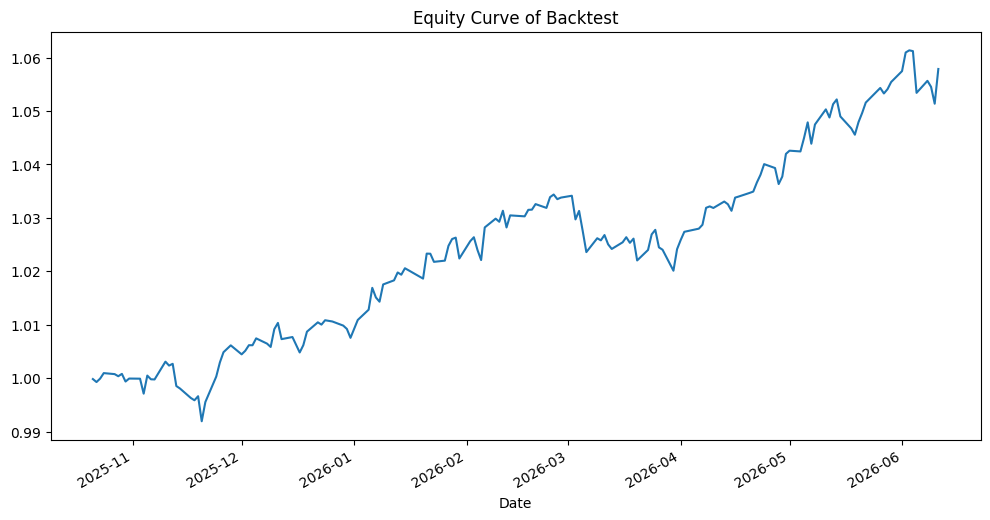

In [40]:
equity_curve.plot(title="Equity Curve of Backtest", figsize=(12, 6))